In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

# Access Aperture4 Simulation Data

This notebook demonstrates how to access variables from Aperture4 simulation output in `/data/personal/Alex_Chen/Torus/Data_vert_B0.6_pair/`.

We use the analysis tools from `analysis_folder` and `Aperture4/external/Aperture_plotting`.

In [2]:
# Add Aperture4 python modules to path
sys.path.insert(0, '/home/aaron/Research/Aperture4/python')
sys.path.insert(0, '/home/aaron/Research/Aperture4/external/Aperture_plotting')

# Add current analysis folder to path
sys.path.insert(0, '/home/aaron/Research/Aperture4/problems/gr_2d_kerr_schild/analysis_folder')

print("Python paths configured:")
for p in sys.path[:3]:
    print(f"  {p}")

Python paths configured:
  /home/aaron/Research/Aperture4/problems/gr_2d_kerr_schild/analysis_folder
  /home/aaron/Research/Aperture4/external/Aperture_plotting
  /home/aaron/Research/Aperture4/python


In [655]:
# Import the Kerr-Schild data loader from the analysis folder
import datalib_gr_ks as ks

# Also import base datalib for reference
from datalib import Data, flag_to_species

## Define Data Directory and Inspect Contents

The simulation data is stored in `/data/personal/Alex_Chen/Torus/Data_vert_B0.6_pair/`.

In [656]:
# Define the data directory
data_dir = "/data/personal/Alex_Chen/Torus/Data_vert_B0.6_pair/"

# Check what files are available
import glob
fld_files = sorted(glob.glob(os.path.join(data_dir, "fld.*.h5")))[:5]
ptc_files = sorted(glob.glob(os.path.join(data_dir, "ptc.*.h5")))[:5]

print(f"Data directory: {data_dir}")
print(f"\nFirst 5 field files:")
for f in fld_files:
    print(f"  {os.path.basename(f)}")
print(f"\nFirst 5 particle files:")
for f in ptc_files:
    print(f"  {os.path.basename(f)}")

# Check for grid and config files
print(f"\nGrid file exists: {os.path.exists(os.path.join(data_dir, 'grid.h5'))}")
print(f"Config file exists: {os.path.exists(os.path.join(data_dir, 'config.toml'))}")

Data directory: /data/personal/Alex_Chen/Torus/Data_vert_B0.6_pair/

First 5 field files:
  fld.00000.h5
  fld.00001.h5
  fld.00002.h5
  fld.00003.h5
  fld.00004.h5

First 5 particle files:
  ptc.00000.h5
  ptc.00001.h5
  ptc.00002.h5
  ptc.00003.h5
  ptc.00004.h5

Grid file exists: True
Config file exists: True


## Load Simulation Data with `DataKerrSchild`

We use the `DataKerrSchild` class from `datalib_gr_ks.py` to load the simulation data. This class:
- Reads the configuration from `config.toml`
- Loads the grid from `grid.h5`
- Sets up Kerr-Schild metric quantities
- Provides lazy loading of field and particle variables

In [657]:
# Load the simulation data
print("Loading data... this may take a moment")
data = ks.DataKerrSchild(data_dir)

print(f"\nData loaded successfully!")
print(f"Black hole spin (a): {data.a}")
print(f"Outer horizon radius (rH): {data.rH}")
print(f"Number of field steps: {len(data.fld_steps)}")
print(f"Field steps range: {data.fld_steps[0]} to {data.fld_steps[-1]}")
print(f"Number of particle steps: {len(data.ptc_steps)}")
print(f"Particle steps range: {data.ptc_steps[0]} to {data.ptc_steps[-1]}")

# Show configuration parameters
print(f"\nConfiguration keys:")
for key in data.conf.keys():
    print(f"  {key}: {data.conf[key]}")

Loading data... this may take a moment


/home/aaron/Research/Aperture4/problems/gr_2d_kerr_schild/analysis_folder/datalib_gr_ks.py:79: RuntimeWarning: divide by zero encountered in divide
  return 1.0/Sigma(r,th,a)/np.sin(th)**2



Data loaded successfully!
Black hole spin (a): 0.998
Outer horizon radius (rH): 1.0632139225171164
Number of field steps: 2649
Field steps range: 0 to 2648
Number of particle steps: 2649
Particle steps range: 0 to 2648

Configuration keys:
  log_level: 0
  dt: 0.00025
  max_steps: 12000000
  fld_output_interval: 4000
  ptc_output_interval: 4000
  snapshot_interval: 40000
  rho_interval: 1
  max_ptc_num: 300000000
  max_ph_num: 100000000
  ptc_buffer_size: 10000000
  ph_buffer_size: 10000000
  ptc_segment_size: 20000000
  ph_segment_size: 20000000
  max_tracked_num: 4000000
  current_smoothing: 5
  tracked_fraction: 0.01
  q_e: 1.0
  bh_spin: 0.998
  use_implicit: True
  implicit_beta: 0.53
  ranks: [1, 4]
  N: [4096, 4096]
  size: [4.45, 3.141592654]
  lower: [0.0, 0.0]
  guard: [2, 2]
  periodic_boundary: [False, False]
  damping_length: 64
  damping_coef: 0.005
  damping_length_horizon: 16
  damping_coef_horizon: 0.01
  damp_to_background: True
  downsample: 2
  output_dir: Data_ver

## Access and Inspect Available Variables

The `DataKerrSchild` class provides access to field data, particle data, mesh data, and computed quantities.

In [658]:
# List all available variable keys
print("Available field keys:")
print(data._fld_keys)

print("\nAvailable particle keys:")
print(data._ptc_keys)

print("\nAvailable mesh keys:")
print(data._mesh_keys)

# Access a field variable (lazy loading - only loads when accessed)
print("\n--- Accessing field variables ---")
print(f"Rho_e shape: {data.Rho_e.shape}")
print(f"Rho_p shape: {data.Rho_p.shape}")
print(f"E1 shape: {data.E1.shape}")
print(f"B1 shape: {data.B1.shape}")

# Access computed quantities
print("\n--- Accessing computed quantities ---")
print(f"plasma_beta shape: {data.plasma_beta.shape}")
print(f"n_proper shape: {data.n_proper.shape}")

# Access mesh coordinates
print("\n--- Mesh coordinates ---")
print(f"x1 (R = r*sin(theta)) shape: {data.x1.shape}")
print(f"x2 (z = r*cos(theta)) shape: {data.x2.shape}")
print(f"_rv (r) shape: {data._rv.shape}")
print(f"_thetav (theta) shape: {data._thetav.shape}")

Available field keys:
['B1', 'B2', 'B3', 'B_sqr', 'Bmag', 'DdotB', 'E1', 'E2', 'E3', 'E_sqr', 'J01', 'J02', 'J03', 'J1', 'J2', 'J3', 'Jmag', 'Rho_e', 'Rho_p', 'Rho_ph', 'Rho_total', 'auxE1', 'auxE2', 'auxE3', 'auxH1', 'auxH2', 'auxH3', 'divB', 'divE', 'flux', 'flux_e1', 'flux_e2', 'flux_e3', 'flux_p1', 'flux_p2', 'flux_p3', 'flux_ph1', 'flux_ph2', 'flux_ph3', 'num_e', 'num_p', 'num_ph', 'pair_produced', 'photon_produced', 'step', 'stress_e00', 'stress_e01', 'stress_e02', 'stress_e03', 'stress_e11', 'stress_e12', 'stress_e13', 'stress_e22', 'stress_e23', 'stress_e33', 'stress_p00', 'stress_p01', 'stress_p02', 'stress_p03', 'stress_p11', 'stress_p12', 'stress_p13', 'stress_p22', 'stress_p23', 'stress_p33', 'stress_ph00', 'stress_ph01', 'stress_ph02', 'stress_ph03', 'stress_ph11', 'stress_ph12', 'stress_ph13', 'stress_ph22', 'stress_ph23', 'stress_ph33', 'time', 'fluxB', 'Dd1', 'Dd2', 'Dd3', 'D', 'Bd1', 'Bd2', 'Bd3', 'B', 'Ed1', 'Ed2', 'Ed3', 'Hd1', 'Hd2', 'Hd3', 'sigma', 'flux_upper', 'f

/home/aaron/Research/Aperture4/problems/gr_2d_kerr_schild/analysis_folder/datalib_gr_ks.py:318: RuntimeWarning: invalid value encountered in divide
  b1 = -u_lower[...,0] * B[...,1] / alpha_val - (u_lower[...,2] * E[...,3] - u_lower[...,3] * E[...,2]) / alpha_val / sqrt_gm
/home/aaron/Research/Aperture4/problems/gr_2d_kerr_schild/analysis_folder/datalib_gr_ks.py:319: RuntimeWarning: invalid value encountered in divide
  b2 = -u_lower[...,0] * B[...,2] / alpha_val - (u_lower[...,3] * E[...,1] - u_lower[...,1] * E[...,3]) / alpha_val / sqrt_gm
/home/aaron/Research/Aperture4/problems/gr_2d_kerr_schild/analysis_folder/datalib_gr_ks.py:320: RuntimeWarning: invalid value encountered in divide
  b3 = -u_lower[...,0] * B[...,3] / alpha_val - (u_lower[...,1] * E[...,2] - u_lower[...,2] * E[...,1]) / alpha_val / sqrt_gm
/home/aaron/Research/Aperture4/problems/gr_2d_kerr_schild/analysis_folder/datalib_gr_ks.py:345: RuntimeWarning: invalid value encountered in divide
  b_upper = self.frf_B / bnorm

plasma_beta shape: (2048, 2048)
n_proper shape: (2048, 2048)

--- Mesh coordinates ---
x1 (R = r*sin(theta)) shape: (2048, 2048)
x2 (z = r*cos(theta)) shape: (2048, 2048)
_rv (r) shape: (2048, 2048)
_thetav (theta) shape: (2048, 2048)


## Extract Fields into NumPy Arrays

You can extract any field variable into a NumPy array for further analysis or custom visualization.

In [659]:
# Extract specific fields into numpy arrays
rho_e = data.Rho_e
rho_p = data.Rho_p
E1 = data.E1
B1 = data.B1
B2 = data.B2
B3 = data.B3

# Computed quantities
beta = data.plasma_beta
n_proper = data.n_proper

# Get coordinates
R = data.x1  # cylindrical radius = r * sin(theta)
z = data.x2  # height = r * cos(theta)

print("Extracted arrays:")
print(f"  rho_e: shape={rho_e.shape}, min={np.min(rho_e):.3e}, max={np.max(rho_e):.3e}")
print(f"  rho_p: shape={rho_p.shape}, min={np.min(rho_p):.3e}, max={np.max(rho_p):.3e}")
print(f"  E1: shape={E1.shape}, min={np.min(E1):.3e}, max={np.max(E1):.3e}")
print(f"  B1: shape={B1.shape}, min={np.min(B1):.3e}, max={np.max(B1):.3e}")
print(f"  plasma_beta: shape={beta.shape}, min={np.min(beta):.3e}, max={np.max(beta):.3e}")
print(f"  n_proper: shape={n_proper.shape}, min={np.min(n_proper):.3e}, max={np.max(n_proper):.3e}")

# You can also compute your own quantities
B_magnitude = np.sqrt(B1**2 + B2**2 + B3**2)
print(f"\nCustom computed B_magnitude: shape={B_magnitude.shape}, min={np.min(B_magnitude):.3e}, max={np.max(B_magnitude):.3e}")

Extracted arrays:
  rho_e: shape=(2048, 2048), min=-1.175e+03, max=0.000e+00
  rho_p: shape=(2048, 2048), min=0.000e+00, max=1.174e+03
  E1: shape=(2048, 2048), min=-1.102e-01, max=9.723e-02
  B1: shape=(2048, 2048), min=-5.931e-01, max=5.931e-01
  plasma_beta: shape=(2048, 2048), min=nan, max=nan
  n_proper: shape=(2048, 2048), min=0.000e+00, max=2.191e+03

Custom computed B_magnitude: shape=(2048, 2048), min=6.949e-03, max=6.898e-01


## Load Different Time Steps

You can load different time steps using `load_fld()` for field data and `load_ptc()` for particle data.

In [660]:
# Example: Load a different field step
step_to_load = data.fld_steps[10]  # Load the 11th step
print(f"Loading field step: {step_to_load}")
data.load_fld(step_to_load)

# Now data.Rho_e etc. will return values from the newly loaded step
rho_e_new = data.Rho_e
print(f"New rho_e shape: {rho_e_new.shape}")
print(f"New rho_e min: {np.min(rho_e_new):.3e}, max: {np.max(rho_e_new):.3e}")

# Load back the first step
data.load_fld(data.fld_steps[0])
print(f"\nReloaded initial step: {data.fld_steps[0]}")

# Time series example: get a time series of a field quantity
print("\n--- Time series example ---")
print("To get a time series, you can use data.time_series_fld('Rho_e')")
print("This returns a list of arrays for each field step.")
print(f"Total field steps available: {len(data.fld_steps)}")
print(f"Steps: {data.fld_steps[:5]} ... {data.fld_steps[-5:]}")

Loading field step: 10
New rho_e shape: (2048, 2048)
New rho_e min: -1.362e+03, max: 0.000e+00

Reloaded initial step: 0

--- Time series example ---
To get a time series, you can use data.time_series_fld('Rho_e')
This returns a list of arrays for each field step.
Total field steps available: 2649
Steps: [0, 1, 2, 3, 4] ... [2644, 2645, 2646, 2647, 2648]


# Calculating Thermal Synchrotron Emission

## Mathematical Background

Starting from the thermal electron distribution

$$
N(\gamma)=\frac{n\gamma^2\beta e^{-\gamma/\theta_e}}{\theta_e K_2(\theta_e^{-1})},
$$

and the emissivity

$$
j^{\alpha\beta}=\int_0^\infty N(\gamma)\,\epsilon^{\alpha\beta}\,d\gamma,
$$

where

- The single-particle emissivity is
  $$
  \epsilon^{\alpha\beta}=\frac{\sqrt{3}e^2}{8\pi c}\nu_B\sin\theta_B\,H^{\alpha\beta}(\nu,\theta_B),
  $$
  with
  $$
  H^{11}=F\!\left(\frac{\nu}{\nu_c}\right)-G\!\left(\frac{\nu}{\nu_c}\right),\qquad
  H^{22}=F\!\left(\frac{\nu}{\nu_c}\right)+G\!\left(\frac{\nu}{\nu_c}\right),\qquad
  H^{12}=-H^{21}=\frac{4i\cot\theta_B}{3\gamma}H\!\left(\frac{\nu}{\nu_c}\right).
  $$

- $\gamma$ and $\beta$ are the electron Lorentz factor and corresponding velocity factor, while the dimensionless electron temperature is
  $$
  \theta_e=\frac{kT}{mc^2}.
  $$

- The emitted frequency is $\nu$, with
  $$
  \nu_c=\frac{3}{2}\nu_B\sin\theta_B\,\gamma^2,\qquad
  \nu_B=\frac{eB}{2\pi mc}.
  $$

- The synchrotron functions are
  $$
  F(x)=x\int_x^\infty K_{5/3}(y)\,dy,\qquad
  G(x)=xK_{2/3}(x),\qquad
  H(x)=\int_x^\infty K_{1/3}(y)\,dy+xK_{1/3}(x).
  $$

Since we only care about intensity (and not polarization), we need only

$$
j_I=j^{22}+j^{11}.
$$

Following a very similar process, but without the earlier two assumptions, we can follow my notes (which are still probably off by a factor of $2\pi$ compared to Dexter) to obtain

$$
j_I=\frac{1}{2\pi}\frac{ne^2}{c\sqrt{3}\,K_2(\theta_e^{-1})\,\theta_e}\,\nu\,I_I(x),
$$

where

$$
I_I(x)=\frac{1}{x}\int_{1/\theta_e}^\infty F\!\left(\frac{x}{z^2}\right)z\sqrt{z^2\theta_e^2-1}\,e^{-z}\,dz,
\qquad
x=\frac{\nu}{\nu_c'},
\qquad
\nu_c'=\frac{\nu_c}{z^2} = \frac{3}{2}\nu_B \sin(\theta_B)\theta_e^2.
$$

Note that I drop the $2\pi$ in further calculations to match Dexter

## Theoretical Calculation

In [2]:
from scipy.integrate import quad, quad_vec
from scipy.special import kv
from scipy.interpolate import CubicSpline
from scipy.optimize import minimize_scalar

### Starting Stuff

In [3]:
#Constants
c = 3e10 #cm/s
m_e = 9.11e-28 #g
q_e = 4.8e-10 #esu

In [4]:
#Values from simulation
n = 1e7 # 1/cm^3
B = 10. # Gauss
theta_e = 10. 
theta_B = np.pi/3.

#nu/nu_c' min and max values
minnuRel = 1e-4; maxnuRel = 1e4 

In [5]:
#Basic Functions
def nuB(B):
    """ Magnetogryation frequency """
    return q_e*B/(2.*np.pi*m_e*c)

def nuc(B, gamma, theta_B):
    """ Characteristic synchrotron frequency """
    return 1.5*nuB(B)*np.sin(theta_B)*gamma*gamma

def nuc_prime(B, theta_e, theta_B):
    """ Characteristic synchrotron frequency (primed) """
    return 1.5*nuB(B)*np.sin(theta_B)*theta_e*theta_e

In [105]:
def build_F_table(xmin=1e-10, xmax=1e10, N=20000):

    xgrid = np.logspace(np.log10(xmin), np.log10(xmax), N)
    Fgrid = np.zeros_like(xgrid)

    for i, x in enumerate(xgrid):
        val, _ = quad(lambda t: kv(5.0/3.0, x + t),  # shifted variable (stable!)
            0.0, np.inf, epsabs=1e-11, epsrel=1e-11)
        Fgrid[i] = x * val

    # remove any numerical pathologies
    mask = np.isfinite(Fgrid) & (Fgrid > 0)
    spline = CubicSpline(np.log(xgrid[mask]), np.log(Fgrid[mask]), extrapolate=True)
    def F_exact(x):
        # Clip to table domain to avoid wild extrapolation
        x = np.clip(x, xmin, xmax)
        return np.exp(spline(np.log(x)))
    return F_exact

# build once
F = build_F_table()

/tmp/ipykernel_1539171/1468620430.py:7: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  val, _ = quad(lambda t: kv(5.0/3.0, x + t),  # shifted variable (stable!)
/tmp/ipykernel_1539171/1468620430.py:7: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  val, _ = quad(lambda t: kv(5.0/3.0, x + t),  # shifted variable (stable!)
/tmp/ipykernel_1539171/1468620430.py:7: IntegrationWarning: The algorithm does not converge.  Roundoff error is detected
  in the extrapolation table.  It is assumed that the requested tolerance
  cannot be achieved, and that the ret

In [7]:
#Thermal Synchrotron Integral and Total Emissivity (normal)
def I_Islow(x, theta_e):
    def outer_integrand(z):
        def inner_integrand(u): return kv(5.0 / 3.0, u)
        inner, _ = quad(inner_integrand, x / z**2, np.inf)
        res = np.sqrt(z**2 * theta_e**2 - 1.0)*np.exp(-z)*inner/z
        return res

    result, _ = quad(outer_integrand, 1./theta_e, np.inf)
    return result

def jIslow(nu, n, B, theta_e, theta_B):
    nu_c = nuc_prime(B, theta_e, theta_B)
    x = nu/nu_c
    top = n*q_e*q_e * nu * I_Islow(x, theta_e)
    bot = np.sqrt(3.)*kv(2., 1/theta_e)*c * theta_e
    return top/bot

In [37]:
# Thermal Synchrotron Integral and Total Emissivity (more accurate)
def II_vec(x, theta_e):
    # x can be an array; vectorize the z integral with quad_vec
    x = np.atleast_1d(x)
    
    def integrand(z, x_arr):
        y = x_arr / z**2
        return F(y) * z * np.sqrt(theta_e**2 * z**2 - 1.) * np.exp(-z)
    
    result, _ = quad_vec(integrand, 1./theta_e, np.inf, args=(x,), epsabs=1e-11, epsrel=1e-11)
    return result / x

def jI(nu, n, B, theta_e, theta_B, nuOvernucp=[]):
    nu_c = nuc_prime(B, theta_e, theta_B)
    x = nu / nu_c
    if(len(nuOvernucp) != 0): x = nuOvernucp; nu = x*nu_c
    prefactor = (n * q_e**2 * nu / (np.sqrt(3.)*kv(2., 1./theta_e)*c*theta_e))
    # II_vec handles both scalar and array x
    return prefactor * II_vec(x, theta_e)

In [9]:
nuOvernucp = np.logspace(np.log10(minnuRel), np.log10(maxnuRel), 100)
nu = nuOvernucp * nuc_prime(B, theta_e, theta_B)

# j_Islow = np.array([jIslow(freq, n, B, theta_e, theta_B) for freq in nu])
j_I = jI(nu, n, B, theta_e, theta_B)

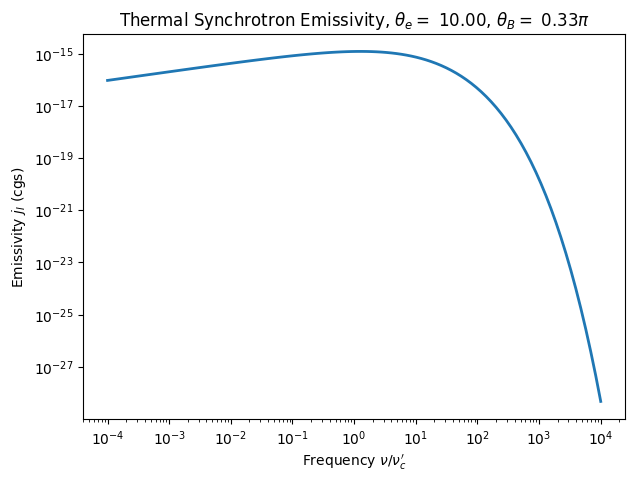

In [10]:
plt.figure(figsize=(7, 5))
plt.loglog(nuOvernucp, j_I, linewidth=2)
plt.xlabel(r"Frequency $\nu/\nu_c'$")
plt.ylabel(r'Emissivity $j_I$ (cgs)')
plt.title(fr'Thermal Synchrotron Emissivity, $\theta_e =$ {theta_e:.2f}, $\theta_B =$ {theta_B/np.pi:.2f}$\pi$')
plt.show()

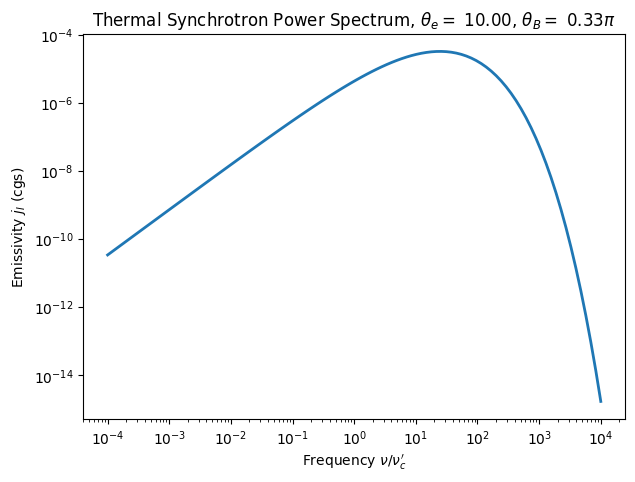

In [11]:
plt.figure(figsize=(7, 5))
plt.loglog(nuOvernucp, nu*j_I, linewidth=2)
plt.xlabel(r"Frequency $\nu/\nu_c'$")
plt.ylabel(r'Emissivity $j_I$ (cgs)')
plt.title(fr'Thermal Synchrotron Power Spectrum, $\theta_e =$ {theta_e:.2f}, $\theta_B =$ {theta_B/np.pi:.2f}$\pi$')
plt.show()

### Ranging over $\theta_B$

In [12]:
theta_Bs = np.arcsin(np.linspace(0.01, 0.999, 5))
angle_Bs = 180./np.pi * theta_Bs # np.array([15., 30., 45., 60., 90.])
nus = np.array([nuOvernucp*nuc_prime(B, theta_e, thB) for thB in theta_Bs])
j_Is = np.array([jI(nus[i], n, B, theta_e, theta_Bs[i]) for i in range(len(theta_Bs))])

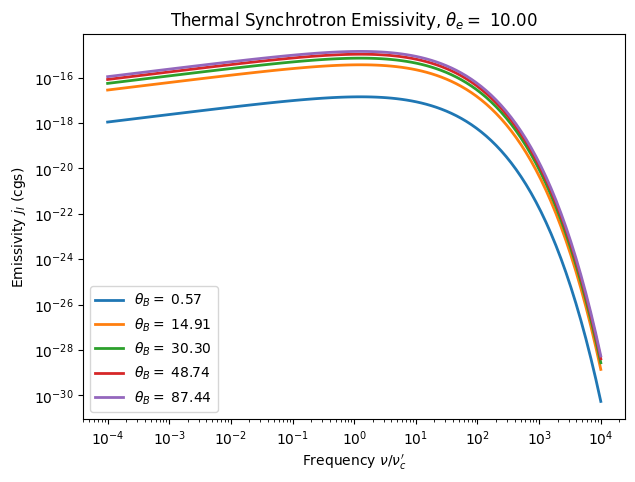

In [13]:
plt.figure(figsize=(7, 5))
[plt.loglog(nuOvernucp, j_Is[i], linewidth=2, label=fr"$\theta_B =$ {angle_Bs[i]:.2f}") for i in range(len(j_Is))]
plt.xlabel(r"Frequency $\nu/\nu_c'$")
plt.ylabel(r'Emissivity $j_I$ (cgs)')
plt.title(fr'Thermal Synchrotron Emissivity, $\theta_e =$ {theta_e:.2f}')
plt.legend()
plt.show()

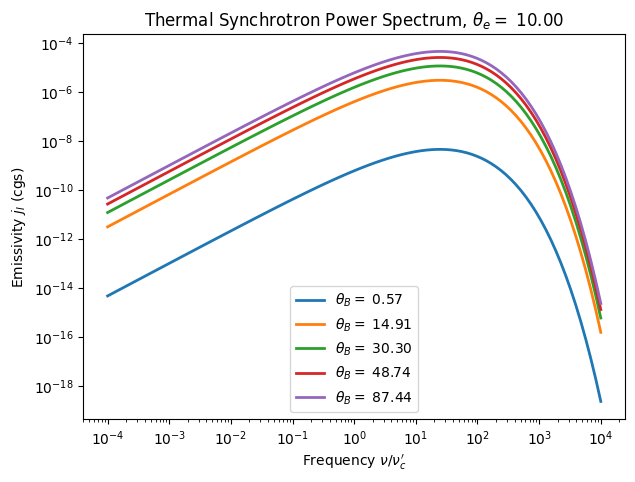

In [14]:
plt.figure(figsize=(7, 5))
[plt.loglog(nuOvernucp, nus[i]*j_Is[i], linewidth=2, label=fr"$\theta_B =$ {angle_Bs[i]:.2f}") for i in range(len(j_Is))]
plt.xlabel(r"Frequency $\nu/\nu_c'$")
plt.ylabel(r'Emissivity $j_I$ (cgs)')
plt.title(fr'Thermal Synchrotron Power Spectrum, $\theta_e =$ {theta_e:.2f}')
plt.legend()
plt.show()

### Finding maximums along $\theta_B$

In [15]:
# Equivalently, we find the minimum of the negative
# Precompute II(x) on a log grid once per theta_e, then reuse for any theta_B
_x_grid = np.logspace(np.log10(minnuRel), np.log10(maxnuRel), 2000)

def build_ii_cache(theta_e):
    _ii_grid = II_vec(_x_grid, theta_e)
    ii_spline = CubicSpline(np.log(_x_grid), np.log(_ii_grid))
    return ii_spline

def maxvals(theta_e, theta_B, printVals=False):
    nu_c = nuc_prime(B, theta_e, theta_B)
    ii_spline = build_ii_cache(theta_e)
    
    def jI_from_x(x):
        prefactor =  n * q_e**2 * (x * nu_c) / (np.sqrt(3.)*kv(2., 1/theta_e)*c*theta_e)
        # Use cached spline; clip to valid log range
        logx = np.clip(np.log(x), np.log(_x_grid[0]), np.log(_x_grid[-1]))
        return float(prefactor * np.exp(ii_spline(logx)))
    
    neg_jI = lambda x: -jI_from_x(x)
    res_emiss = minimize_scalar(neg_jI, bounds=(minnuRel, maxnuRel), method='bounded')
    neg_PS = lambda x: -(x * nu_c) * jI_from_x(x)
    res_PS = minimize_scalar(neg_PS, bounds=(minnuRel, maxnuRel), method='bounded')

    if(printVals):
        print(f"--- Emissivity + Power Spectrum Peak ---")
        print(f"x = nu/nu_c' = {res_emiss.x:.6f}, {res_PS.x:.6f}")
        print(f"Peak Value (cgs): {-res_emiss.fun:.6e}, {-res_PS.fun:.6e}")
    return -res_emiss.fun, -res_PS.fun

In [16]:
theta_e = 10.
maxvals(theta_e, theta_B, True);

--- Emissivity + Power Spectrum Peak ---
x = nu/nu_c' = 1.271322, 24.621263
Peak Value (cgs): 1.229327e-15, 3.327901e-05


In [17]:
def _peak_pair(theta_e, theta_B, ii_spline=None, get_pos=False):
    """Compute peak emissivity and power spectrum for a single (theta_e, theta_B) pair."""
    nu_c = nuc_prime(B, theta_e, theta_B)
    if ii_spline is None:
        ii_spline = build_ii_cache(theta_e)

    def jI_from_x(x):
        prefactor = n * q_e**2 * (x * nu_c) / (np.sqrt(3.)*kv(2., 1/theta_e)*c*theta_e)
        logx = np.clip(np.log(x), np.log(_x_grid[0]), np.log(_x_grid[-1]))
        return float(prefactor * np.exp(ii_spline(logx)))

    neg_jI = lambda x: -jI_from_x(x)
    res_emiss = minimize_scalar(neg_jI, bounds=(minnuRel, maxnuRel), method='bounded')
    neg_PS = lambda x: -(x * nu_c) * jI_from_x(x)
    res_PS = minimize_scalar(neg_PS, bounds=(minnuRel, maxnuRel), method='bounded')

    if get_pos:
        return -res_emiss.fun, -res_PS.fun, res_emiss.x, res_PS.x
    return -res_emiss.fun, -res_PS.fun

def returnPeaks(theta_es, theta_Bs, get_pos=False, theta_B_first=True):
    theta_e_arr = np.atleast_1d(theta_es)
    theta_B_arr = np.atleast_1d(theta_Bs)

    # Both scalar
    if theta_e_arr.size == 1 and theta_B_arr.size == 1:
        return _peak_pair(float(theta_e_arr[0]), float(theta_B_arr[0]), get_pos=get_pos)

    # Scalar theta_e, array theta_Bs  (backward-compatible path)
    if theta_e_arr.size == 1:
        te = float(theta_e_arr[0])
        ii_spline = build_ii_cache(te)
        out = [_peak_pair(te, float(tb), ii_spline=ii_spline, get_pos=get_pos) for tb in theta_B_arr]
        if get_pos:
            return tuple(np.array([o[i] for o in out]) for i in range(4))
        return tuple(np.array([o[i] for o in out]) for i in range(2))

    # Array theta_e, scalar theta_B
    if theta_B_arr.size == 1:
        tb = float(theta_B_arr[0])
        out = [_peak_pair(float(te), tb, get_pos=get_pos) for te in theta_e_arr]
        if get_pos:
            return tuple(np.array([o[i] for o in out]) for i in range(4))
        return tuple(np.array([o[i] for o in out]) for i in range(2))

    # Both arrays
    n_te, n_tb = len(theta_e_arr), len(theta_B_arr)
    if theta_B_first:
        # output shape: (n_tb, n_te)
        if get_pos:
            j_peaks = np.empty((n_tb, n_te))
            PS_peaks = np.empty((n_tb, n_te))
            j_xpeaks = np.empty((n_tb, n_te))
            PS_xpeaks = np.empty((n_tb, n_te))
            for i, tb in enumerate(theta_B_arr):
                for j, te in enumerate(theta_e_arr):
                    j_peaks[i, j], PS_peaks[i, j], j_xpeaks[i, j], PS_xpeaks[i, j] = \
                        _peak_pair(float(te), float(tb), get_pos=True)
            return j_peaks, PS_peaks, j_xpeaks, PS_xpeaks
        else:
            j_peaks = np.empty((n_tb, n_te))
            PS_peaks = np.empty((n_tb, n_te))
            for i, tb in enumerate(theta_B_arr):
                for j, te in enumerate(theta_e_arr):
                    j_peaks[i, j], PS_peaks[i, j] = _peak_pair(float(te), float(tb), get_pos=False)
            return j_peaks, PS_peaks
    else:
        # output shape: (n_te, n_tb)
        if get_pos:
            j_peaks = np.empty((n_te, n_tb))
            PS_peaks = np.empty((n_te, n_tb))
            j_xpeaks = np.empty((n_te, n_tb))
            PS_xpeaks = np.empty((n_te, n_tb))
            for i, te in enumerate(theta_e_arr):
                for j, tb in enumerate(theta_B_arr):
                    j_peaks[i, j], PS_peaks[i, j], j_xpeaks[i, j], PS_xpeaks[i, j] = \
                        _peak_pair(float(te), float(tb), get_pos=True)
            return j_peaks, PS_peaks, j_xpeaks, PS_xpeaks
        else:
            j_peaks = np.empty((n_te, n_tb))
            PS_peaks = np.empty((n_te, n_tb))
            for i, te in enumerate(theta_e_arr):
                for j, tb in enumerate(theta_B_arr):
                    j_peaks[i, j], PS_peaks[i, j] = _peak_pair(float(te), float(tb), get_pos=False)
            return j_peaks, PS_peaks

def peak_plot(x_var, peaks, i, label_var, plot_along=None,
              sin_plot=False, logx=True, logy=True, extraLabel=""):
    """
    Plot peak emissivity / power spectrum.

    Parameters
    ----------
    x_var : float or array
        Variable on the x-axis (theta_B or theta_e).
    peaks : array or list/tuple of arrays
        Y data. 1D array, list of 1D arrays, or 2D array.
    i : int
        0 = emissivity peak, 1 = power spectrum peak.
    label_var : float or array
        Variable used for curve labels (theta_e or theta_B).
    plot_along : {None, 'x_var', 'label_var'}, optional
        For 2D ``peaks`` only: which axis slices into curves.
        * 'x_var'   – each column is a curve; x-axis is ``x_var``.
        * 'label_var' – each row is a curve; x-axis is ``label_var``.
        If None, auto-detected from shape matching.
    sin_plot : bool
        Plot sin(x_var) on the x-axis.
    logx, logy : bool
        Log scales.
    extraLabel : str or sequence
        Extra text appended to each legend entry.
    """
    x_arr = np.atleast_1d(x_var)
    label_arr = np.atleast_1d(label_var)

    # ---- decide what the variables represent (heuristic) ----
    def _is_theta_B(arr):
        return np.all((arr >= 0) & (arr <= np.pi + 0.1))

    x_is_theta_B = _is_theta_B(x_arr)
    label_is_theta_B = _is_theta_B(label_arr)

    # ---- normalise extraLabel ----
    if not isinstance(extraLabel, (list, tuple)):
        extraLabel = (extraLabel,) * max(len(label_arr), 1)
    else:
        extraLabel = tuple(extraLabel)

    # ---- unpack peaks ----
    peaks_is_list = isinstance(peaks, (list, tuple))
    if peaks_is_list:
        # list/tuple of 1-D arrays  (e.g. [actual, fit])
        curves = [np.atleast_1d(p) for p in peaks]
        x_data = x_arr
        labels = label_arr
    else:
        peaks_arr = np.asarray(peaks)
        if peaks_arr.ndim < 2:
            # single 1-D curve
            if len(x_arr) == 1 and len(label_arr) > 1:
                # scalar x, array label  -> swap so array is on the axis
                x_arr, label_arr = label_arr, x_arr
                x_is_theta_B, label_is_theta_B = label_is_theta_B, x_is_theta_B
            curves = [np.atleast_1d(peaks_arr)]
            x_data = x_arr
            labels = label_arr
        else:
            # 2-D array  -> both x_var and label_var are arrays
            if plot_along is None:
                if len(x_arr) == peaks_arr.shape[0]:
                    plot_along = 'x_var'
                elif len(x_arr) == peaks_arr.shape[1]:
                    plot_along = 'label_var'
                else:
                    raise ValueError(
                        "Cannot auto-determine plot_along from shapes. "
                        "Pass plot_along='x_var' or plot_along='label_var'."
                    )

            if plot_along == 'label_var':
                # want label_var on x-axis, curves for each x_var
                if peaks_arr.shape == (len(x_arr), len(label_arr)):
                    peaks_arr = peaks_arr.T
                x_arr, label_arr = label_arr, x_arr
                x_is_theta_B, label_is_theta_B = label_is_theta_B, x_is_theta_B

            # now peaks_arr should be (len(x_arr), len(label_arr))
            if peaks_arr.shape != (len(x_arr), len(label_arr)):
                if peaks_arr.shape == (len(label_arr), len(x_arr)):
                    peaks_arr = peaks_arr.T
                else:
                    raise ValueError(
                        f"peaks shape {peaks_arr.shape} incompatible with "
                        f"({len(x_arr)}, {len(label_arr)})"
                    )

            curves = [peaks_arr[:, j] for j in range(peaks_arr.shape[1])]
            x_data = x_arr
            labels = label_arr

    # ---- plot ----
    plt.figure(figsize=(7, 5))
    if logx:
        plt.xscale('log')
    if logy:
        plt.yscale('log')

    x_plot = np.sin(x_data) if sin_plot else x_data
    x_label_str = r"$\theta_B$" if x_is_theta_B else r"$\theta_e$"
    label_prefix = r"$\theta_B =$ " if label_is_theta_B else r"$\theta_e =$ "

    for j, curve in enumerate(curves):
        val = float(labels[j]) if np.ndim(labels[j]) == 0 else float(labels[j].flat[0])
        if label_is_theta_B:
            lbl = label_prefix + f"{np.degrees(val):.1f}°" + str(extraLabel[j])
        else:
            lbl = label_prefix + f"{val:.2f}" + str(extraLabel[j])
        plt.plot(x_plot, curve, lw=2, label=lbl, marker="o")

    plt.xlabel(r"$\sin \theta_B$" if sin_plot else x_label_str)
    lbl_title = ["Peak emissivity $j_I$", "Power Law Peak"]
    plt.ylabel(f'{lbl_title[i]} (cgs)')
    plt.legend()
    plt.show()

In [18]:
theta_Bs = np.flip(np.arcsin(np.logspace(-2, np.log10(0.999), 20)))
j_peaks, PS_peaks = returnPeaks(theta_e, theta_Bs)

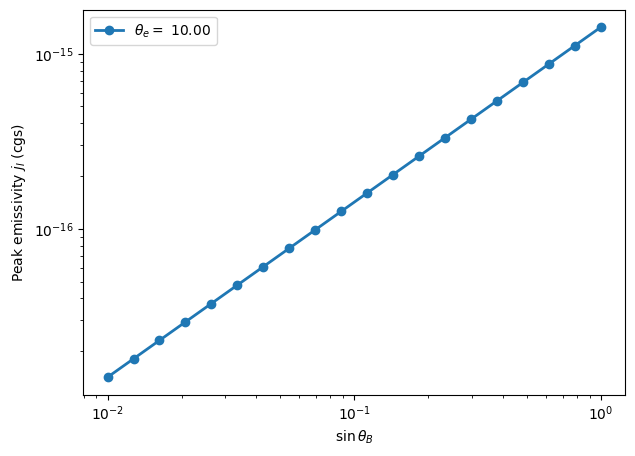

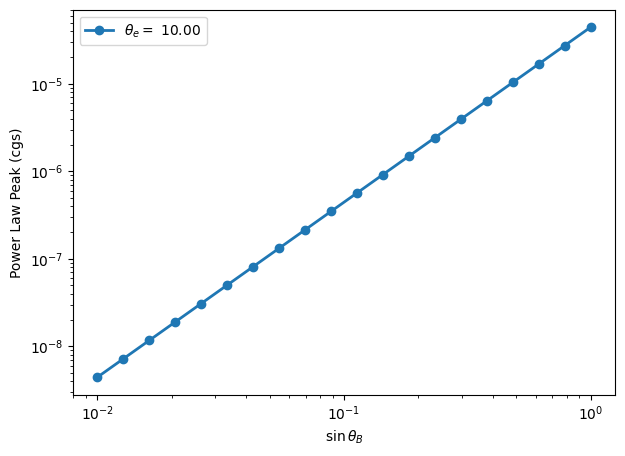

In [19]:
peak_plot(theta_Bs, j_peaks,  0, theta_e, sin_plot=True, logx=True, logy=True)
peak_plot(theta_Bs, PS_peaks, 1, theta_e, sin_plot=True, logx=True, logy=True)

#### Fitting along $\theta_B$

In [20]:
# logthB = np.log10(theta_Bs)
logsinthB = np.log10(np.sin(theta_Bs))
y_j, y_PS = np.log10(j_peaks), np.log10(PS_peaks)
[slope_j, b_j], [ss_res_j,], _, _, _ =   np.polyfit(logsinthB, y_j,  deg=1, full=True)
[slope_PS, b_PS], [ss_res_PS,], _, _, _ = np.polyfit(logsinthB, y_PS, deg=1, full=True)

j_peaks_fit = np.sin(theta_Bs)**slope_j * 10**b_j
PS_peaks_fit = np.sin(theta_Bs)**slope_PS * 10**b_PS

In [21]:
R2 = lambda ss_res, y: 1. - ss_res/np.sum((y - np.mean(y))**2)
print(fr"Slope, intercept, R^2 values")
print(fr"j:  {slope_j:.2f}, {b_j:.2f}, {R2(ss_res_j, y_j):.3f}")
print(fr"PS: {slope_PS:.2f}, {b_PS:.2f}, {R2(ss_res_PS, y_PS):.3f}")

Slope, intercept, R^2 values
j:  1.00, -14.85, 1.000
PS: 2.00, -4.35, 1.000


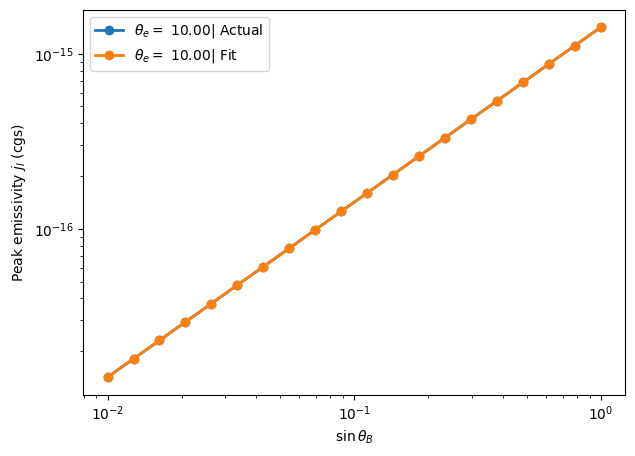

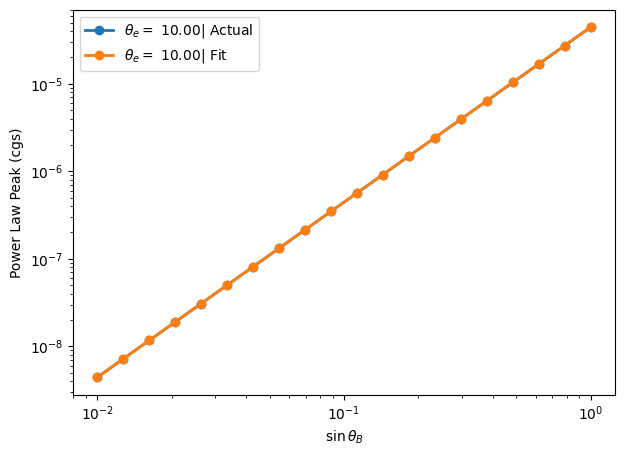

In [22]:
#Should I just ignore the last few points to the fit?
peak_plot(theta_Bs, [j_peaks, j_peaks_fit],   0, [theta_e, theta_e], sin_plot=True, logx=True, logy=True, extraLabel=["| Actual", "| Fit"])
peak_plot(theta_Bs, [PS_peaks, PS_peaks_fit], 1, [theta_e, theta_e], sin_plot=True, logx=True, logy=True, extraLabel=["| Actual", "| Fit"])

### Ranging over $\theta_e$

In [23]:
theta_es = np.logspace(-2, 3, 8)
theta_B = np.pi/3.; angle_B = 180./np.pi * theta_B
nus2 = np.array([nuOvernucp*nuc_prime(B, th_e, theta_B) for th_e in theta_es])
j_Is2 = np.array([jI(nus2[i], n, B, theta_es[i], theta_B) for i in range(len(theta_es))])

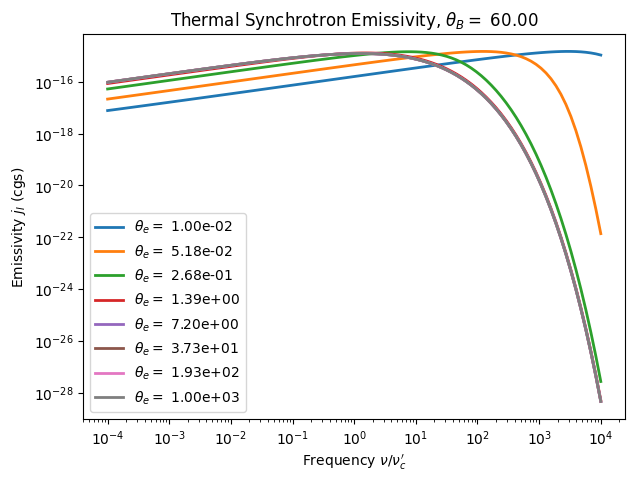

In [24]:
plt.figure(figsize=(7, 5))
[plt.loglog(nuOvernucp, j_Is2[i], linewidth=2, label=fr"$\theta_e =$ {theta_es[i]:.2e}") for i in range(len(j_Is2))]
plt.xlabel(r"Frequency $\nu/\nu_c'$")
plt.ylabel(r'Emissivity $j_I$ (cgs)')
plt.title(fr'Thermal Synchrotron Emissivity, $\theta_B =$ {angle_B:.2f}')
plt.legend()
plt.show()

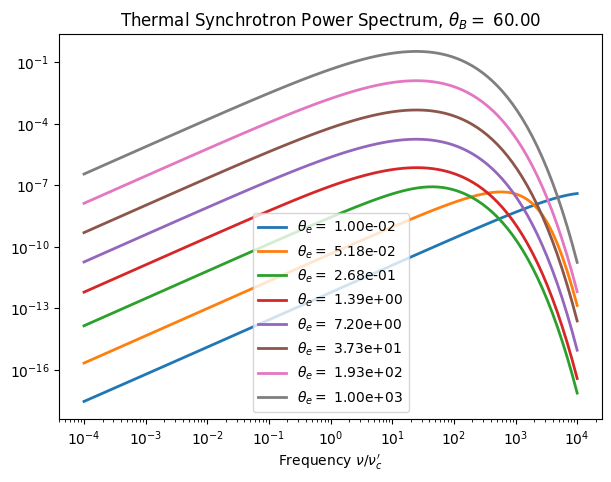

In [25]:
plt.figure(figsize=(7, 5))
[plt.loglog(nuOvernucp, nus2[i]*j_Is2[i], linewidth=2, label=fr"$\theta_e =$ {theta_es[i]:.2e}") for i in range(len(j_Is2))]
plt.xlabel(r"Frequency $\nu/\nu_c'$")
# plt.ylabel(r'Emissivity $j_I$ (cgs)')
plt.title(fr'Thermal Synchrotron Power Spectrum, $\theta_B =$ {angle_B:.2f}')
plt.legend()
plt.show()

### Finding maximums along $\theta_e$

In [26]:
theta_es = np.logspace(-2, 3, 20)
theta_B = np.pi/3.; angle_B = 180./np.pi * theta_B

j_peaks2, PS_peaks2 = returnPeaks(theta_es, theta_B)

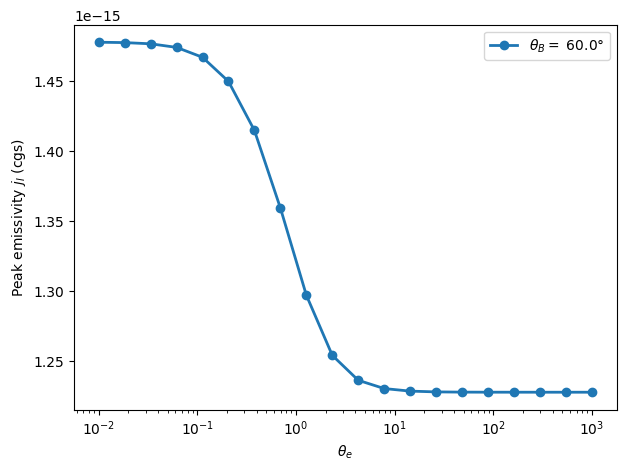

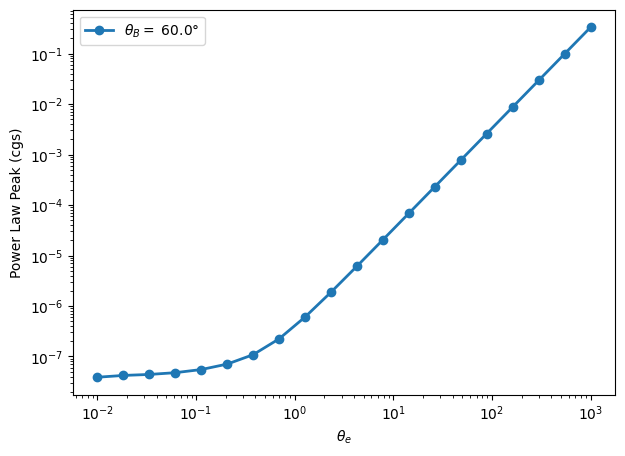

In [27]:
peak_plot(theta_es, j_peaks2,  0, theta_B, sin_plot=False, logx=True, logy=False)
peak_plot(theta_es, PS_peaks2, 1, theta_B, sin_plot=False, logx=True, logy=True)
# plt.loglog(theta_es, theta_es**30)
# plt.loglog(theta_es, 1e-24*theta_es**8)

#### Flipped plots

In [28]:
def normed(arr): return arr/max(arr)

In [29]:
#More points so we can get a better fit
theta_es = np.logspace(-2, 3, 30)
# theta_es = np.linspace(1e-2, 1e3, 30)
theta_Bs = np.flip(np.arcsin(np.logspace(-2, np.log10(0.999), 20)))
peakPeaksP = np.transpose([(returnPeaks(theta_e, theta_Bs,True)) for theta_e in theta_es], (1, 0, 2))
peakPeaksPFlipped = peakPeaksP.transpose((0, 2, 1))

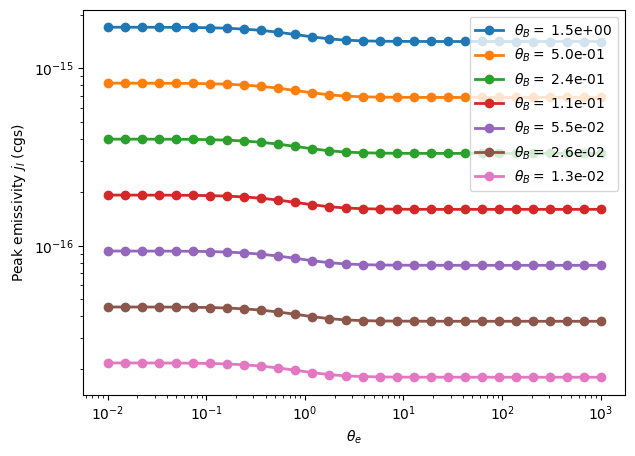

In [30]:
#Flipped plot
plt.figure(figsize=(7, 5))
[plt.plot(theta_es, peakPeaksPFlipped[0][i], lw=2, label=fr"$\theta_B =$ {theta_Bs[i]:.1e} ", marker="o") for i in range(0,len(theta_Bs),3)]
plt.yscale('log'); plt.xscale('log')
plt.xlabel(r"$\theta_e$"); plt.ylabel(fr'Peak emissivity $j_I$ (cgs)')
plt.legend(); plt.show()

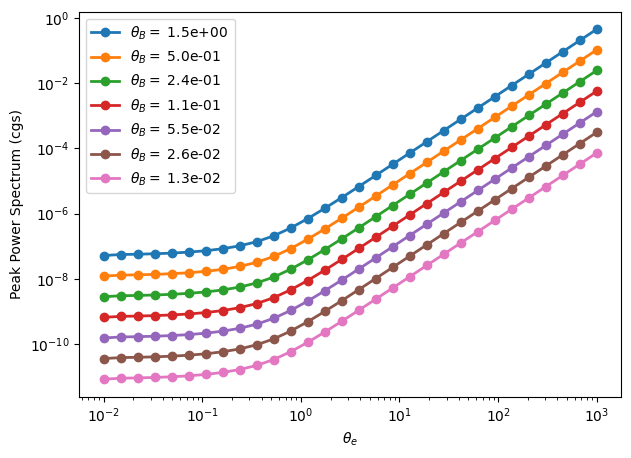

In [31]:
#Flipped plot
plt.figure(figsize=(7, 5))
[plt.plot(theta_es, peakPeaksPFlipped[1][i], lw=2, label=fr"$\theta_B =$ {theta_Bs[i]:.1e} ", marker="o") for i in range(0,len(theta_Bs),3)]
plt.yscale('log'); plt.xscale('log')
plt.xlabel(r"$\theta_e$"); plt.ylabel(fr'Peak Power Spectrum (cgs)')
plt.legend(); plt.show()

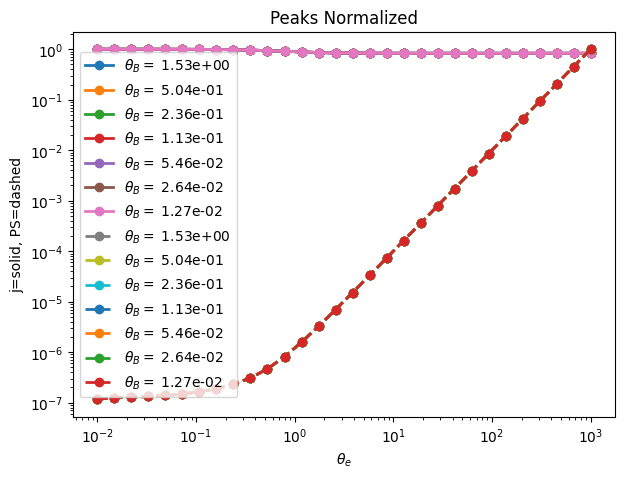

In [32]:
plt.figure(figsize=(7, 5))
[plt.plot(theta_es, normed(peakPeaksPFlipped[0][i]), lw=2, label=fr"$\theta_B =$ {theta_Bs[i]:.2e} ", marker="o") for i in range(0,len(theta_Bs),3)]
[plt.plot(theta_es, normed(peakPeaksPFlipped[1][i]), lw=2, label=fr"$\theta_B =$ {theta_Bs[i]:.2e} ", marker="o",ls="dashed") for i in range(0,len(theta_Bs),3)]
plt.xlabel(r"$\theta_e$"); plt.ylabel(fr'j=solid, PS=dashed')
plt.yscale('log'); plt.xscale('log')
plt.title("Peaks Normalized")
plt.legend(); plt.show()

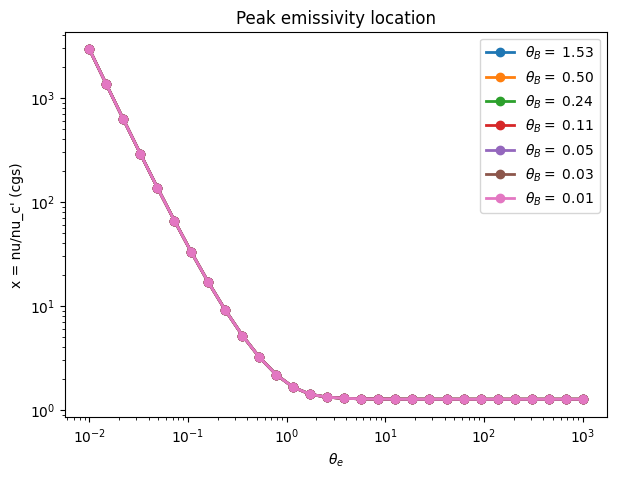

In [33]:
plt.figure(figsize=(7, 5))
[plt.plot(theta_es, peakPeaksPFlipped[2][i], lw=2, label=fr"$\theta_B =$ {theta_Bs[i]:.2f} ", marker="o") for i in range(0,len(theta_Bs),3)]
plt.yscale('log'); plt.xscale('log')
plt.xlabel(r"$\theta_e$"); plt.ylabel(fr"x = nu/nu_c' (cgs)")
plt.title("Peak emissivity location")
plt.legend(); plt.show()

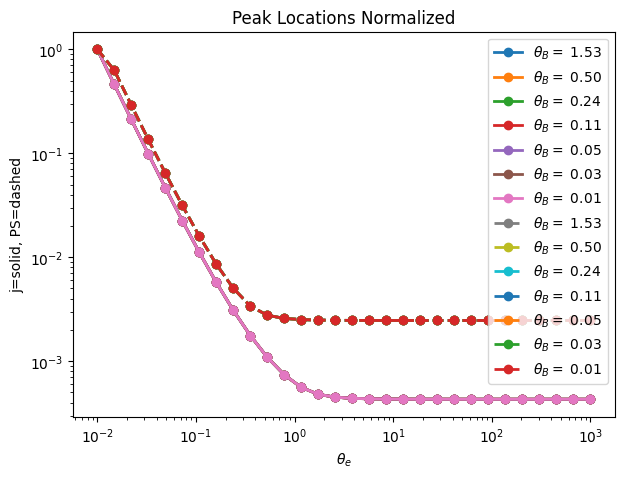

In [34]:
plt.figure(figsize=(7, 5))
[plt.plot(theta_es, normed(peakPeaksPFlipped[2][i]), lw=2, label=fr"$\theta_B =$ {theta_Bs[i]:.2f} ", marker="o") for i in range(0,len(theta_Bs),3)]
[plt.plot(theta_es, normed(peakPeaksPFlipped[3][i]), lw=2, label=fr"$\theta_B =$ {theta_Bs[i]:.2f} ", marker="o",ls="dashed") for i in range(0,len(theta_Bs),3)]
plt.yscale('log'); plt.xscale('log')
plt.xlabel(r"$\theta_e$"); plt.ylabel(fr'j=solid, PS=dashed')
plt.title("Peak Locations Normalized")
plt.legend(); plt.show()

#### Fitting along $\theta_e$

We actually don't do this (at least not right now)

#### Finally getting an approxmation for $j$

In [124]:
nChange = 1e7 # 1/cm^3
BChange = 10. # Gauss
theta_eChange = 10.
theta_BChange = np.pi/3.
C0 = (nChange * q_e**2 / (np.sqrt(3.)*kv(2., 1./theta_eChange)*c*theta_eChange))

In [125]:
from scipy.optimize import curve_fit
def emis_model(log_nu, log_nu0, C, j0):
    return C0*C*F(10**(log_nu - log_nu0))+j0

def get_fit(emis_model, data, ind_var, init_guess=[], bounds=None):
    x_data = np.log10(ind_var)
    y_data = np.log10(data)
    def log_model(x, *params):
        return np.log10(emis_model(x, *params))
    if bounds is None:
        # Keep nu/nu0 inside [1e-10, 1e10] relative to data range
        log_nu_min, log_nu_max = np.log10(np.min(ind_var)), np.log10(np.max(ind_var))
        bounds = ([log_nu_max - 10, 0., 0.],
                  [log_nu_min + 10, np.inf, np.inf])
    popt, pcov = curve_fit(log_model, x_data, y_data, p0=init_guess, bounds=bounds)
    return popt, np.sqrt(np.diag(pcov))

def err_string(val, abs_err, typ):
    if(typ==1):    return f"{val:.2f} +/- {1e2*abs_err/val:.2f}%"
    return f"{val:.2e} +/- {1e2*abs_err/val:.2f}%"

In [126]:
ind_var = nuOvernucp*nuc_prime(BChange, theta_eChange, theta_BChange)
data = jI(1., nChange, BChange, theta_eChange, theta_BChange, nuOvernucp)

In [127]:
# Use nuc_prime as a sensible initial guess for nu0
nu_c_prime = nuc_prime(BChange, theta_eChange, theta_BChange)
popt, errs = get_fit(emis_model, data, ind_var, init_guess=[np.log10(nu_c_prime), 1e10, 0.])
print(popt)
print(errs)
log_nu0, C, j0 = popt

[3.63301867e+00 2.81388317e+07 2.16406428e-13]
[0.0000000e+00 0.0000000e+00 1.5753621e-09]


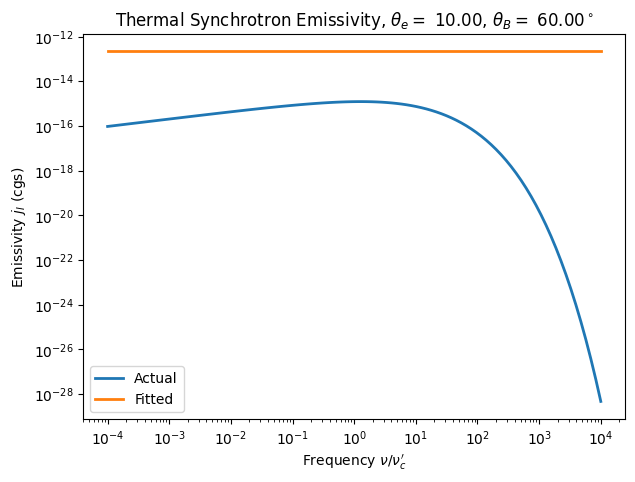

In [128]:
plt.figure(figsize=(7, 5))
plt.loglog(nuOvernucp, jI(2., nChange, BChange, theta_eChange, theta_BChange, nuOvernucp), lw=2, label="Actual")
# plt.loglog(nuOvernucp, emis_model(np.log10(ind_var), np.log10(1e12), 1e10, 0.), lw=2, label="By Eye")
plt.loglog(nuOvernucp, emis_model(np.log10(ind_var), log_nu0, C, j0), lw=2, label="Fitted")
plt.xlabel(r"Frequency $\nu/\nu_c'$"); plt.xscale('log'); plt.yscale('log')
plt.ylabel(r'Emissivity $j_I$ (cgs)')
plt.title(fr'Thermal Synchrotron Emissivity, $\theta_e =$ {theta_e:.2f}, $\theta_B =$ {180*theta_B/np.pi:.2f}$^\circ$')
plt.legend()
plt.show()

In [129]:
print(f"Function: C*C0*F(nu/nu0)+j0")
# log_nu0, C, j0
print(f"Curve Fit: nu0 = {err_string(10**log_nu0,10**errs[0],1)}, C = {err_string(C,errs[1],1)}, j0 = {err_string(j0,errs[2],1)}")

Function: C*C0*F(nu/nu0)+j0
Curve Fit: nu0 = 4295.55 +/- 0.02%, C = 28138831.67 +/- 0.00%, j0 = 0.00 +/- 727964.56%


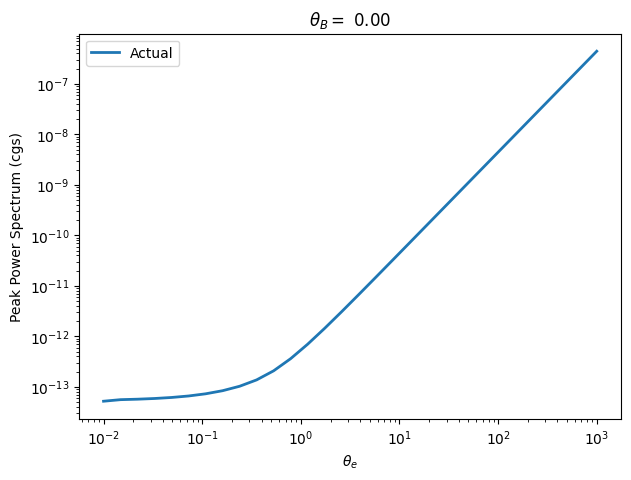

In [40]:
#Flipped plot
plt.figure(figsize=(7, 5))
plt.plot(theta_es, peakPeaksPFlipped[1][0], lw=2, label=fr"Actual")
A_JS = 5e-11; C_JS = .4e0; delta_JS = 2.96; gam_JS = 1.17
# plt.plot(theta_es, emis_model(theta_es, A_JS, delta_JS, C_JS, gam_JS), lw=2, label=fr"Manual Fit",ls="dashed")
plt.title(fr"$\theta_B =$ {theta_Bs[0]:.2f}")
plt.yscale('log'); plt.xscale('log')
plt.xlabel(r"$\theta_e$"); plt.ylabel(fr'Peak Power Spectrum (cgs)')
plt.legend(); plt.show()

In [41]:
def jI_model(nu, n, B, theta_e, theta_B, fit_e, fit_B):
    A0, d, c, gamm = fit_e
    slope, b = fit_B

    F_thetaB = theta_B**slope * 10**b
    F_thetae = A0*theta_e**d * np.exp(-c/theta_e**gamm)
    return F_thetaB*F_thetae

TODO: 

Figure out where I can apply fancy new peak_plot function

Full run-through of entire notebook and make sure things are symmetric/make sense/actually run

Check with AI about $\theta_B \to \pi$ and $0$ limits

Finally, figure out how to incorperate nu into my fitting functions, before smashing them together to approximate $j$